# Squared-Conflict RT Model


In [28]:
import os, glob, warnings
import numpy as np
import pandas as pd
import scipy.io as sio
from scipy.optimize import minimize
from scipy.stats import pearsonr
import matplotlib.pyplot as plt

DATA_DIR = r"C:\Users\234355\Downloads\DD_data"        

In [29]:
COLS = ["r_imm", "r_del", "delay", "choice", "p_imm", "condition", "rt"]

def load_participant_mat(fpath):
    mat = sio.loadmat(fpath, squeeze_me=True, struct_as_record=False)
    def get(mat, opts):
        for o in opts:
            if o in mat:
                return np.asarray(mat[o])
        raise KeyError(f"None of {opts} found in {fpath}: keys={list(mat.keys())}")
    train = get(mat, ["data_train", "dataTrain"])
    test  = get(mat, ["data_test", "dataTest"])
    ncol = min(train.shape[1], len(COLS))
    df_train = pd.DataFrame(train[:, :ncol], columns=COLS[:ncol])
    df_test  = pd.DataFrame(test[:, :ncol],  columns=COLS[:ncol])
    for df in (df_train, df_test):
        if df["rt"].median() > 20: 
            df["rt"] = df["rt"] / 1000.0
    return df_train, df_test


def normalise_rewards(df_train, df_test):
    scale = max(df_train.r_imm.max(), df_train.r_del.max())
    for df in (df_train, df_test):
        df["r_imm"] = df["r_imm"] / scale
        df["r_del"] = df["r_del"] / scale
    return df_train, df_test, scale


def clean(df):
    df = df[(df.choice.isin([1, 2])) & (df.rt > 0)].reset_index(drop=True)
    return df


In [30]:
def hyperbolic_dV(r_imm, r_del, delay, k, condition):
    sign = np.where(np.asarray(condition) == 2, -1.0, 1.0)
    SV_del = sign * r_del / (1.0 + k * delay)
    SV_imm = sign * r_imm
    return SV_del - SV_imm


def choice_prob_delayed(dV, gamma):
    return 1.0 / (1.0 + np.exp(-np.clip(gamma * dV, -700, 700)))


In [31]:
def rt_loglik_squared_conflict(rt, dV, a, b, sigma, t0):
    if np.any(rt <= t0):
        return -np.inf
    mu = a - b * (dV ** 2)
    z = (np.log(rt - t0) - mu) / sigma
    ll = -np.log(rt - t0) - np.log(sigma) - 0.5 * np.log(2 * np.pi) - 0.5 * z ** 2
    return ll.sum()


def rt_logpdf_squared_conflict(rt, dV, a, b, sigma, t0):
    out = np.full_like(rt, -np.inf, dtype=float)
    valid = rt > t0
    mu = a - b * (dV ** 2)
    z = (np.log(rt[valid] - t0) - mu[valid]) / sigma
    out[valid] = -np.log(rt[valid] - t0) - np.log(sigma) - 0.5 * np.log(2 * np.pi) - 0.5 * z ** 2
    return out


def simulate_rt_squared_conflict(dV, a, b, sigma, t0, rng):
    mu = a - b * (dV ** 2)
    mu = np.clip(mu, -30, 30)
    return t0 + rng.lognormal(mean=mu, sigma=sigma)


In [34]:
FULL_BOUNDS = [(-6, 4), (-4, 4), (-6, 6), (-6, 6), (-4, 3), (-8, 8)]
CHOICE_BOUNDS = [(-6, 4), (-4, 4)]

def unpack_full(theta, min_rt):
    pk, pg, a, b, psig, pt0 = theta
    k = np.exp(np.clip(pk, -20, 20)); gamma = np.exp(np.clip(pg, -20, 20)); sigma = np.exp(np.clip(psig, -20, 20))
    t0 = 0.98 * min_rt / (1.0 + np.exp(-np.clip(pt0, -30, 30)))
    return k, gamma, a, b, sigma, t0

def unpack_choice_only(theta):
    pk, pg = theta
    return np.exp(np.clip(pk, -20, 20)), np.exp(np.clip(pg, -20, 20))

def nll_full(theta, r_imm, r_del, delay, condition, y_del, rt, min_rt):
    k, gamma, a, b, sigma, t0 = unpack_full(theta, min_rt)
    dV = hyperbolic_dV(r_imm, r_del, delay, k, condition)
    p = np.clip(choice_prob_delayed(dV, gamma), 1e-10, 1 - 1e-10)
    ll_choice = np.sum(y_del * np.log(p) + (1 - y_del) * np.log(1 - p))
    ll_rt = rt_loglik_squared_conflict(rt, dV, a, b, sigma, t0)
    if not np.isfinite(ll_rt):
        return 1e10
    return -(ll_choice + ll_rt)

def nll_choice_only(theta, r_imm, r_del, delay, condition, y_del):
    k, gamma = unpack_choice_only(theta)
    dV = hyperbolic_dV(r_imm, r_del, delay, k, condition)
    p = np.clip(choice_prob_delayed(dV, gamma), 1e-10, 1 - 1e-10)
    ll = np.sum(y_del * np.log(p) + (1 - y_del) * np.log(1 - p))
    return -ll

def _restarts(x0, n, scale, rng):
    return [x0] + [x0 + rng.normal(scale=scale, size=len(x0)) for _ in range(n - 1)]

def fit_full(df, n_restarts=8, rng=RNG):
    r_imm, r_del, delay = df.r_imm.values, df.r_del.values, df.delay.values
    condition, rt = df.condition.values, df.rt.values
    y_del = (df.choice.values == 2).astype(float)
    min_rt = rt.min()
    x0 = np.array([np.log(0.03), np.log(2.0), 0.7, 0.3, np.log(0.35), 0.0])
    best = None
    for x in _restarts(x0, n_restarts, 0.6, rng):
        res = minimize(nll_full, x, args=(r_imm, r_del, delay, condition, y_del, rt, min_rt),
                        method="Nelder-Mead", bounds=FULL_BOUNDS,
                        options=dict(maxiter=6000, xatol=1e-7, fatol=1e-7))
        if best is None or res.fun < best.fun:
            best = res
    k, gamma, a, b, sigma, t0 = unpack_full(best.x, min_rt)
    return dict(k=k, gamma=gamma, a=a, b=b, sigma=sigma, t0=t0, nll=best.fun, converged=bool(best.success))

def fit_choice_only(df, n_restarts=6, rng=RNG):
    r_imm, r_del, delay = df.r_imm.values, df.r_del.values, df.delay.values
    condition = df.condition.values
    y_del = (df.choice.values == 2).astype(float)
    x0 = np.array([np.log(0.03), np.log(2.0)])
    best = None
    for x in _restarts(x0, n_restarts, 0.6, rng):
        res = minimize(nll_choice_only, x, args=(r_imm, r_del, delay, condition, y_del),
                        method="Nelder-Mead", bounds=CHOICE_BOUNDS,
                        options=dict(maxiter=3000, xatol=1e-7, fatol=1e-7))
        if best is None or res.fun < best.fun:
            best = res
    k, gamma = unpack_choice_only(best.x)
    return dict(k=k, gamma=gamma, nll=best.fun, converged=bool(best.success))


In [35]:
participants = {}
mat_files = sorted(glob.glob(os.path.join(DATA_DIR, "*.mat"))) if os.path.isdir(DATA_DIR) else []

if mat_files:
    print(f"Found {len(mat_files)} participant files in '{DATA_DIR}/' ")
    for fp in mat_files:
        pid = os.path.splitext(os.path.basename(fp))[0]
        df_train, df_test = load_participant_mat(fp)
        df_train, df_test, scale = normalise_rewards(clean(df_train), clean(df_test))
        participants[pid] = dict(train=df_train, test=df_test, true_params=None, reward_scale=scale)

Found 81 participant files in 'C:\Users\234355\Downloads\DD_data/' 


In [36]:
fitA_full, fitA_base = {}, {}
for pid, d in participants.items():
    fitA_full[pid] = fit_full(d["train"])
    fitA_base[pid] = fit_choice_only(d["train"])

fitA_full_df = pd.DataFrame(fitA_full).T
fitA_base_df = pd.DataFrame(fitA_base).T
print("Run-A full-model fits (head):")
fitA_full_df.head()


Run-A full-model fits (head):


,k,gamma,a,b,sigma,t0,nll,converged
Sample1_07mpzgefw,0.014147,14.148145,-0.089882,0.451552,0.804472,0.882877,121.984948,True
Sample1_0ow9y3ng4,0.015291,54.59815,0.130164,0.716378,0.552425,0.563403,87.221463,True
Sample1_19j097r6c,0.002832,54.59815,0.071545,0.279315,0.584147,1.551154,90.660225,True
Sample1_1pwx30q0h,0.008685,54.59815,-0.005189,0.483884,0.354063,0.265299,45.250657,True
Sample1_2k3imu1lz,0.008024,54.59815,0.210415,0.389377,0.392663,0.642536,72.363008,True


In [37]:
print(f"Converged: {fitA_full_df.converged.sum()}/{len(fitA_full_df)} (full), "
      f"{fitA_base_df.converged.sum()}/{len(fitA_base_df)} (baseline)")
fitA_full_df[["k", "gamma", "a", "b", "sigma", "t0"]].describe()


Converged: 81/81 (full), 81/81 (baseline)


,k,gamma,a,b,sigma,t0
count,81.000000,81.00000,81.000000,81.000000,81.000000,81.000000
unique,52.000000,63.00000,81.000000,81.000000,81.000000,81.000000
top,0.002479,54.59815,-0.089882,0.451552,0.804472,0.882877
freq,30.000000,18.00000,1.000000,1.000000,1.000000,1.000000


In [38]:
def recover_one(pid, df_design, true_params, rng):
    dV = hyperbolic_dV(df_design.r_imm.values, df_design.r_del.values, df_design.delay.values,
                        true_params["k"], df_design.condition.values)
    p_del = choice_prob_delayed(dV, true_params["gamma"])
    choice = (rng.uniform(size=len(dV)) < p_del).astype(int) + 1
    rt = simulate_rt_squared_conflict(dV, true_params["a"], true_params["b"],
                                       true_params["sigma"], true_params["t0"], rng)
    sim_df = df_design.copy()
    sim_df["choice"] = choice
    sim_df["rt"] = rt
    fit_rt = fit_full(sim_df, n_restarts=6, rng=rng)
    fit_ch = fit_choice_only(sim_df, n_restarts=6, rng=rng)
    return fit_rt, fit_ch

rows = []
for pid, d in participants.items():
    true_params = fitA_full[pid] 
    fit_rt, fit_ch = recover_one(pid, d["train"], true_params, RNG)
    row = {"pid": pid}
    for p in ["k", "gamma", "a", "b", "sigma", "t0"]:
        row[f"true_{p}"] = true_params[p]
        row[f"rec_full_{p}"] = fit_rt[p]
    row["rec_choiceonly_k"] = fit_ch["k"]
    row["rec_choiceonly_gamma"] = fit_ch["gamma"]
    rows.append(row)
recovery_df = pd.DataFrame(rows)
recovery_df.head()


,pid,true_k,rec_full_k,true_gamma,rec_full_gamma,true_a,rec_full_a,true_b,rec_full_b,true_sigma,rec_full_sigma,true_t0,rec_full_t0,rec_choiceonly_k,rec_choiceonly_gamma
0,Sample1_07mpzgefw,0.014147,0.015609,14.148145,11.649536,-0.089882,-0.269125,0.451552,0.627647,0.804472,0.877648,0.882877,0.929084,0.014925,11.813746
1,Sample1_0ow9y3ng4,0.015291,0.019011,54.598150,33.477518,0.130164,0.107883,0.716378,0.212114,0.552425,0.595952,0.563403,0.564181,0.018521,33.906808
2,Sample1_19j097r6c,0.002832,0.004449,54.598150,38.241029,0.071545,-0.190501,0.279315,0.887331,0.584147,0.827713,1.551154,1.810415,0.004665,38.260410
3,Sample1_1pwx30q0h,0.008685,0.008672,54.598150,42.674478,-0.005189,-0.039722,0.483884,0.488120,0.354063,0.349968,0.265299,0.284828,0.008551,42.349374
4,Sample1_2k3imu1lz,0.008024,0.007854,54.598150,44.508342,0.210415,0.641368,0.389377,0.480082,0.392663,0.253704,0.642536,0.000336,0.007863,44.535294


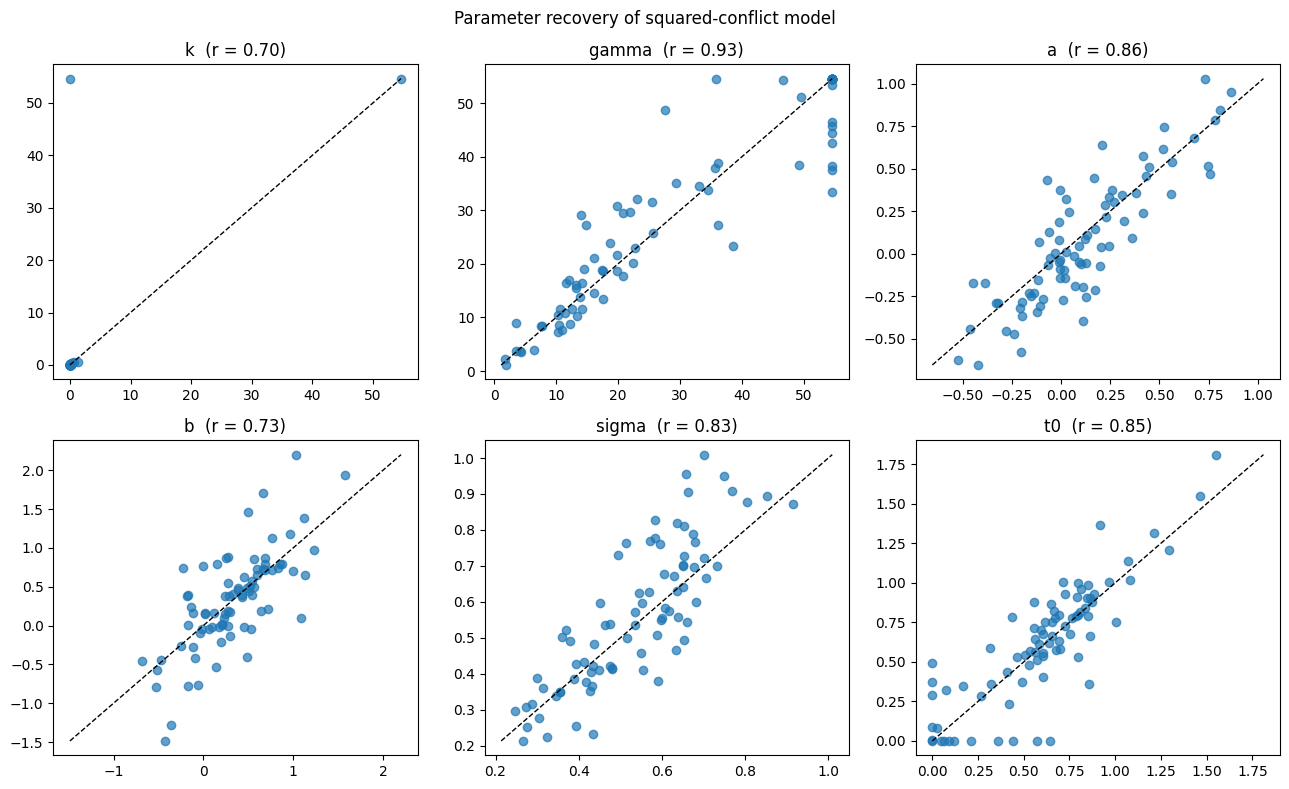


Recovery correlations (full choice+RT model):
  k      r = 0.702
  gamma  r = 0.933
  a      r = 0.856
  b      r = 0.733
  sigma  r = 0.829
  t0     r = 0.849

Recovery correlations (choice-only baseline, k & gamma):
  k      r = 1.000  (choice-only)   vs   0.702  (choice+RT)
  gamma  r = 0.933  (choice-only)   vs   0.933  (choice+RT)


In [39]:
fig, axes = plt.subplots(2, 3, figsize=(13, 8))
params = ["k", "gamma", "a", "b", "sigma", "t0"]
for ax, p in zip(axes.flat, params):
    x, y = recovery_df[f"true_{p}"], recovery_df[f"rec_full_{p}"]
    ax.scatter(x, y, alpha=0.7)
    lims = [min(x.min(), y.min()), max(x.max(), y.max())]
    ax.plot(lims, lims, "k--", lw=1)
    r, _ = pearsonr(x, y)
    ax.set_title(f"{p}  (r = {r:.2f})")
fig.suptitle("Parameter recovery of squared-conflict model")
fig.tight_layout()
plt.savefig("recovery_full_model.png", dpi=150)
plt.show()

print("\nRecovery correlations (full choice+RT model):")
for p in params:
    r, _ = pearsonr(recovery_df[f"true_{p}"], recovery_df[f"rec_full_{p}"])
    print(f"  {p:6s} r = {r:.3f}")

print("\nRecovery correlations (choice-only baseline, k & gamma):")
for p in ["k", "gamma"]:
    r, _ = pearsonr(recovery_df[f"true_{p}"], recovery_df[f"rec_choiceonly_{p}"])
    print(f"  {p:6s} r = {r:.3f}  (choice-only)   vs   "
          f"{pearsonr(recovery_df[f'true_{p}'], recovery_df[f'rec_full_{p}'])[0]:.3f}  (choice+RT)")


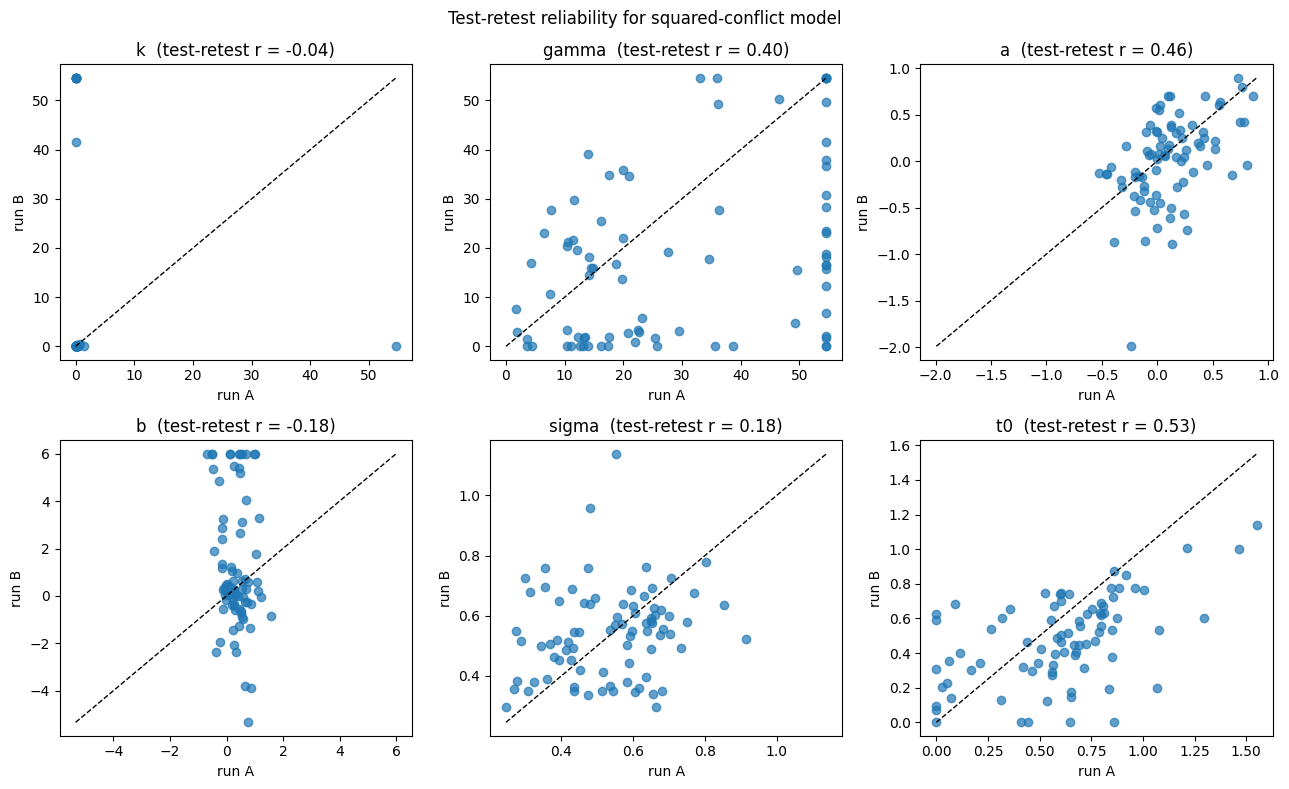

Test-retest reliability (full model):
  k      r = -0.040
  gamma  r = 0.401
  a      r = 0.460
  b      r = -0.182
  sigma  r = 0.180
  t0     r = 0.532

Test-retest reliability (choice-only baseline) vs (choice+RT), k & gamma:
  k      choice-only r = -0.057   |   choice+RT r = -0.040
  gamma  choice-only r = 0.420   |   choice+RT r = 0.401


In [44]:
fitB_full, fitB_base = {}, {}
for pid, d in participants.items():
    fitB_full[pid] = fit_full(d["test"])
    fitB_base[pid] = fit_choice_only(d["test"])

fitB_full_df = pd.DataFrame(fitB_full).T
fitB_base_df = pd.DataFrame(fitB_base).T

fig, axes = plt.subplots(2, 3, figsize=(13, 8))
for ax, p in zip(axes.flat, params):
    x, y = fitA_full_df[p].astype(float), fitB_full_df[p].astype(float)
    ax.scatter(x, y, alpha=0.7)
    lims = [min(x.min(), y.min()), max(x.max(), y.max())]
    ax.plot(lims, lims, "k--", lw=1)
    r, _ = pearsonr(x, y)
    ax.set_title(f"{p}  (test-retest r = {r:.2f})")
    ax.set_xlabel("run A"); ax.set_ylabel("run B")
fig.suptitle("Test-retest reliability for squared-conflict model")
fig.tight_layout()
plt.savefig("reliability_full_model.png", dpi=150)
plt.show()

print("Test-retest reliability (full model):")
for p in params:
    r, _ = pearsonr(fitA_full_df[p].astype(float), fitB_full_df[p].astype(float))
    print(f"  {p:6s} r = {r:.3f}")

print("\nTest-retest reliability (choice-only baseline) vs (choice+RT), k & gamma:")
for p in ["k", "gamma"]:
    r_base, _ = pearsonr(fitA_base_df[p].astype(float), fitB_base_df[p].astype(float))
    r_full, _ = pearsonr(fitA_full_df[p].astype(float), fitB_full_df[p].astype(float))
    print(f"  {p:6s} choice-only r = {r_base:.3f}   |   choice+RT r = {r_full:.3f}")


In [45]:
def choice_pred_loglik(df, k, gamma):
    dV = hyperbolic_dV(df.r_imm.values, df.r_del.values, df.delay.values, k, df.condition.values)
    p = np.clip(choice_prob_delayed(dV, gamma), 1e-10, 1 - 1e-10)
    y = (df.choice.values == 2).astype(float)
    ll = y * np.log(p) + (1 - y) * np.log(1 - p)
    acc = np.mean((p > 0.5).astype(int) == y)
    return ll, acc

def rt_pred_loglik(df, k, gamma, a, b, sigma, t0):
    dV = hyperbolic_dV(df.r_imm.values, df.r_del.values, df.delay.values, k, df.condition.values)
    return rt_logpdf_squared_conflict(df.rt.values, dV, a, b, sigma, t0)

records = []
for pid, d in participants.items():
    df_test = d["test"]
    pf, pb = fitA_full[pid], fitA_base[pid]
    ll_full, acc_full = choice_pred_loglik(df_test, pf["k"], pf["gamma"])
    ll_base, acc_base = choice_pred_loglik(df_test, pb["k"], pb["gamma"])
    ll_rt = rt_pred_loglik(df_test, pf["k"], pf["gamma"], pf["a"], pf["b"], pf["sigma"], pf["t0"])
    cond = df_test.condition.values
    for c_label, c_val in [("overall", None), ("reward", 1), ("loss", 2)]:
        mask = np.ones(len(cond), dtype=bool) if c_val is None else (cond == c_val)
        if mask.sum() == 0:
            continue
        records.append(dict(
            pid=pid, condition=c_label, n_trials=int(mask.sum()),
            choice_ll_full=ll_full[mask].mean(), choice_ll_base=ll_base[mask].mean(),
            choice_acc_full=np.mean((ll_full[mask] > np.log(0.5))),  # per-trial correct-call proxy
            rt_ll_full=np.nanmean(ll_rt[mask][np.isfinite(ll_rt[mask])]) if np.isfinite(ll_rt[mask]).any() else np.nan,
        ))
oos_df = pd.DataFrame(records)
oos_summary = oos_df.groupby("condition")[["choice_ll_full", "choice_ll_base", "rt_ll_full"]].mean()
print("Mean per-trial predictive log-like on run B, by condition:")
oos_summary


Mean per-trial predictive log-like on run B, by condition:


,choice_ll_full,choice_ll_base,rt_ll_full
condition,,,
overall,-0.846607,-0.829181,-1.293819
reward,-0.846607,-0.829181,-1.293819


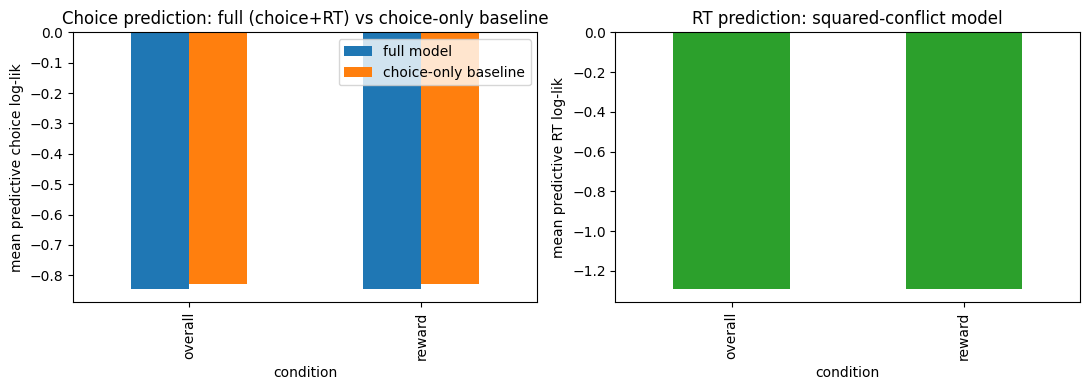

In [46]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
oos_summary[["choice_ll_full", "choice_ll_base"]].plot(kind="bar", ax=ax[0])
ax[0].set_ylabel("mean predictive choice log-lik")
ax[0].set_title("Choice prediction: full (choice+RT) vs choice-only baseline")
ax[0].legend(["full model", "choice-only baseline"])

oos_summary[["rt_ll_full"]].plot(kind="bar", ax=ax[1], legend=False, color="tab:green")
ax[1].set_ylabel("mean predictive RT log-lik")
ax[1].set_title("RT prediction: squared-conflict model")
fig.tight_layout()
plt.savefig("oos_prediction_summary.png", dpi=150)
plt.show()
